Connected to base (Python 3.12.7)

Explained variance by 2 components: [0.4381767  0.31204339]


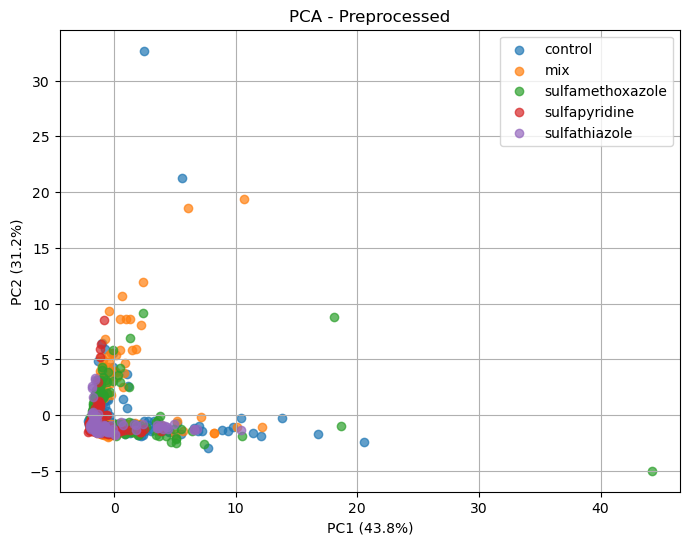

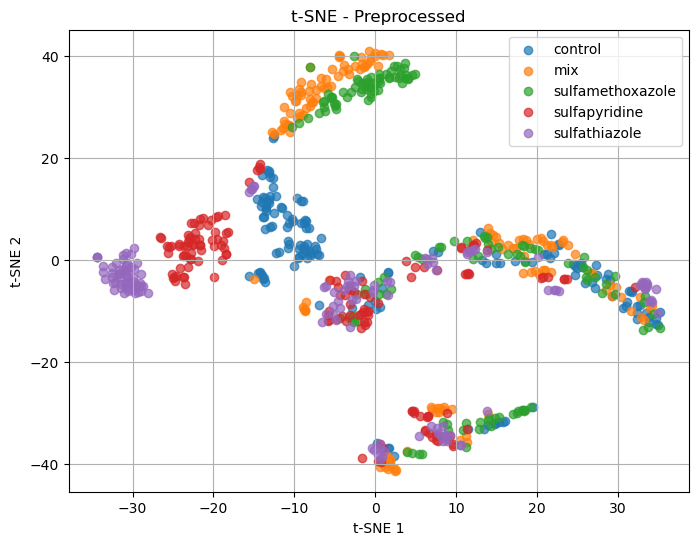

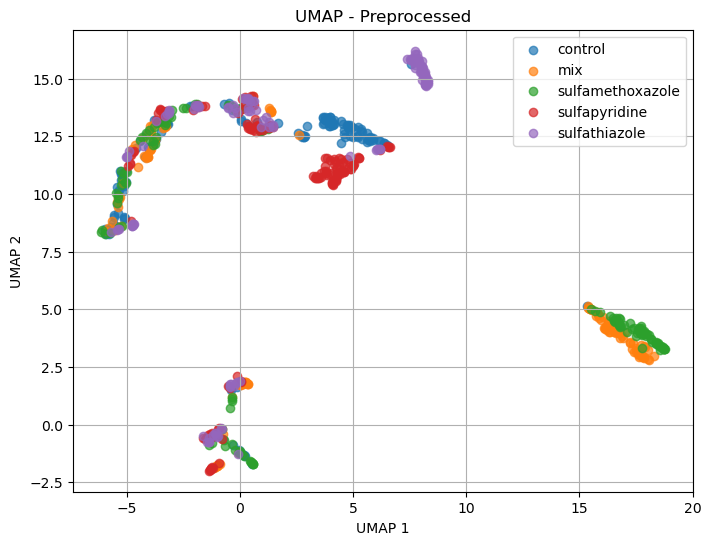

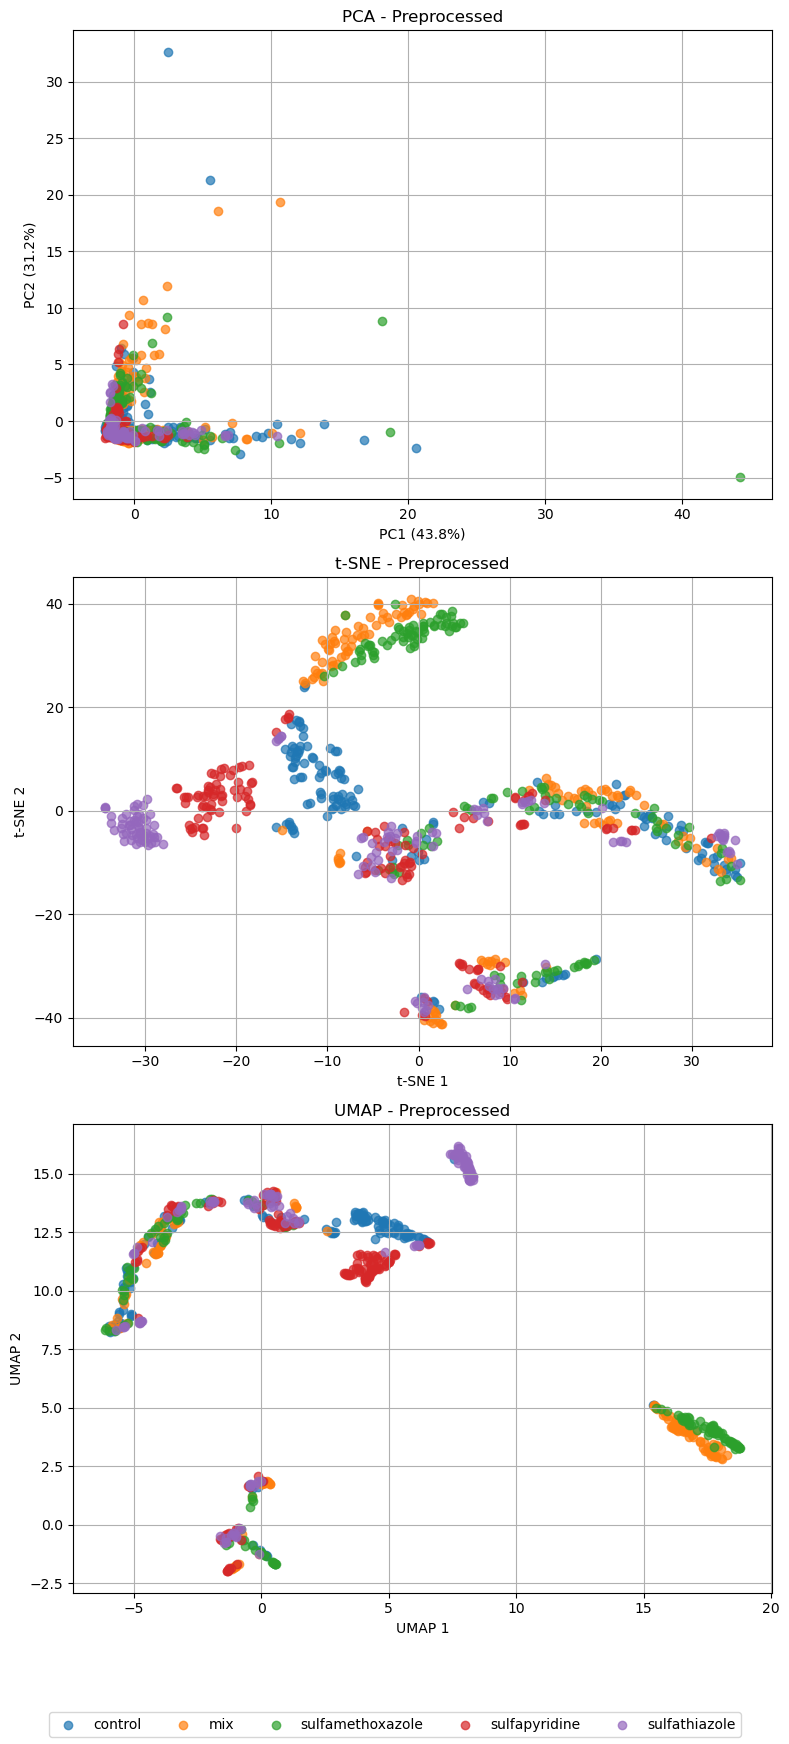

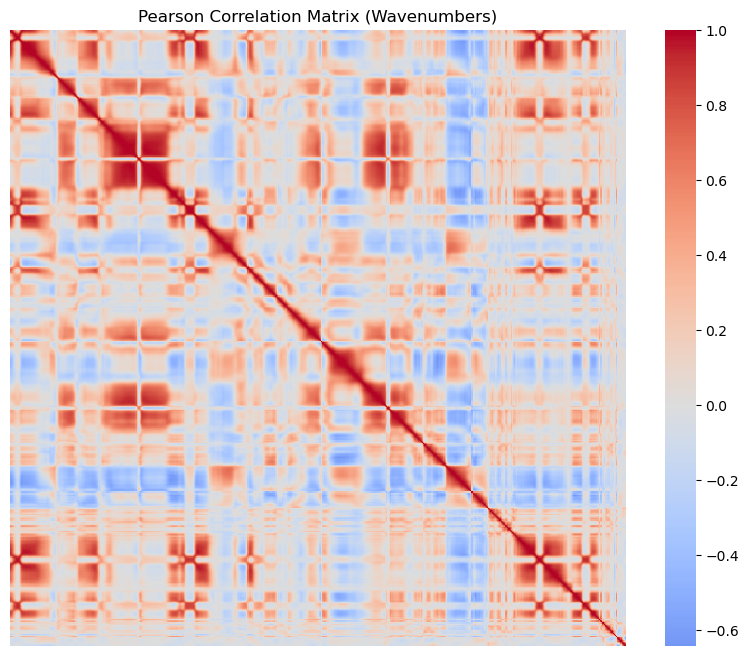

Explained variance by 2 components: [0.81147604 0.06019075]


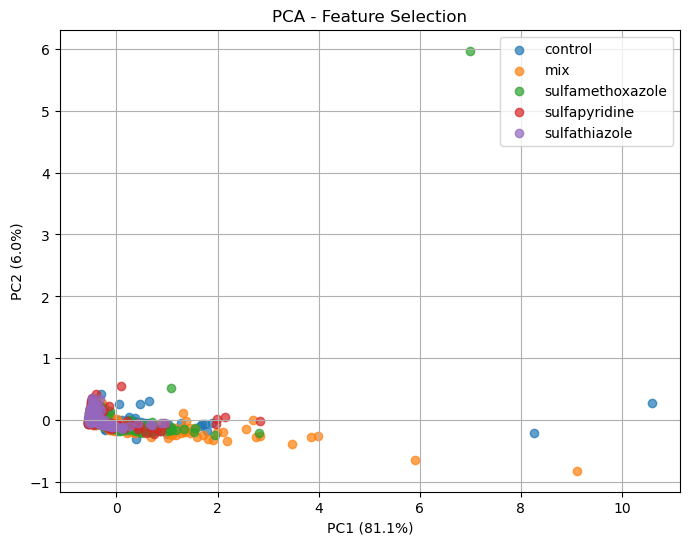

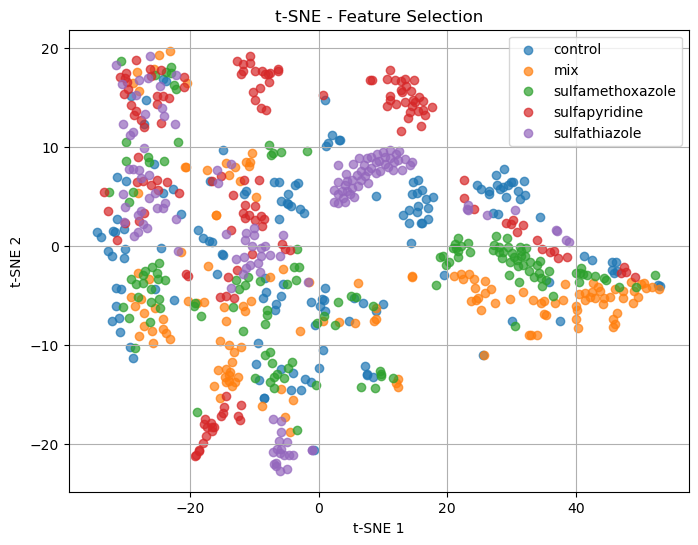

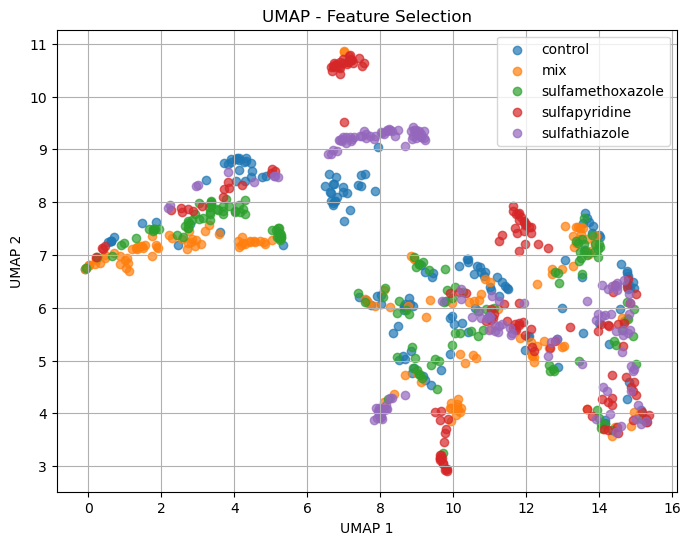

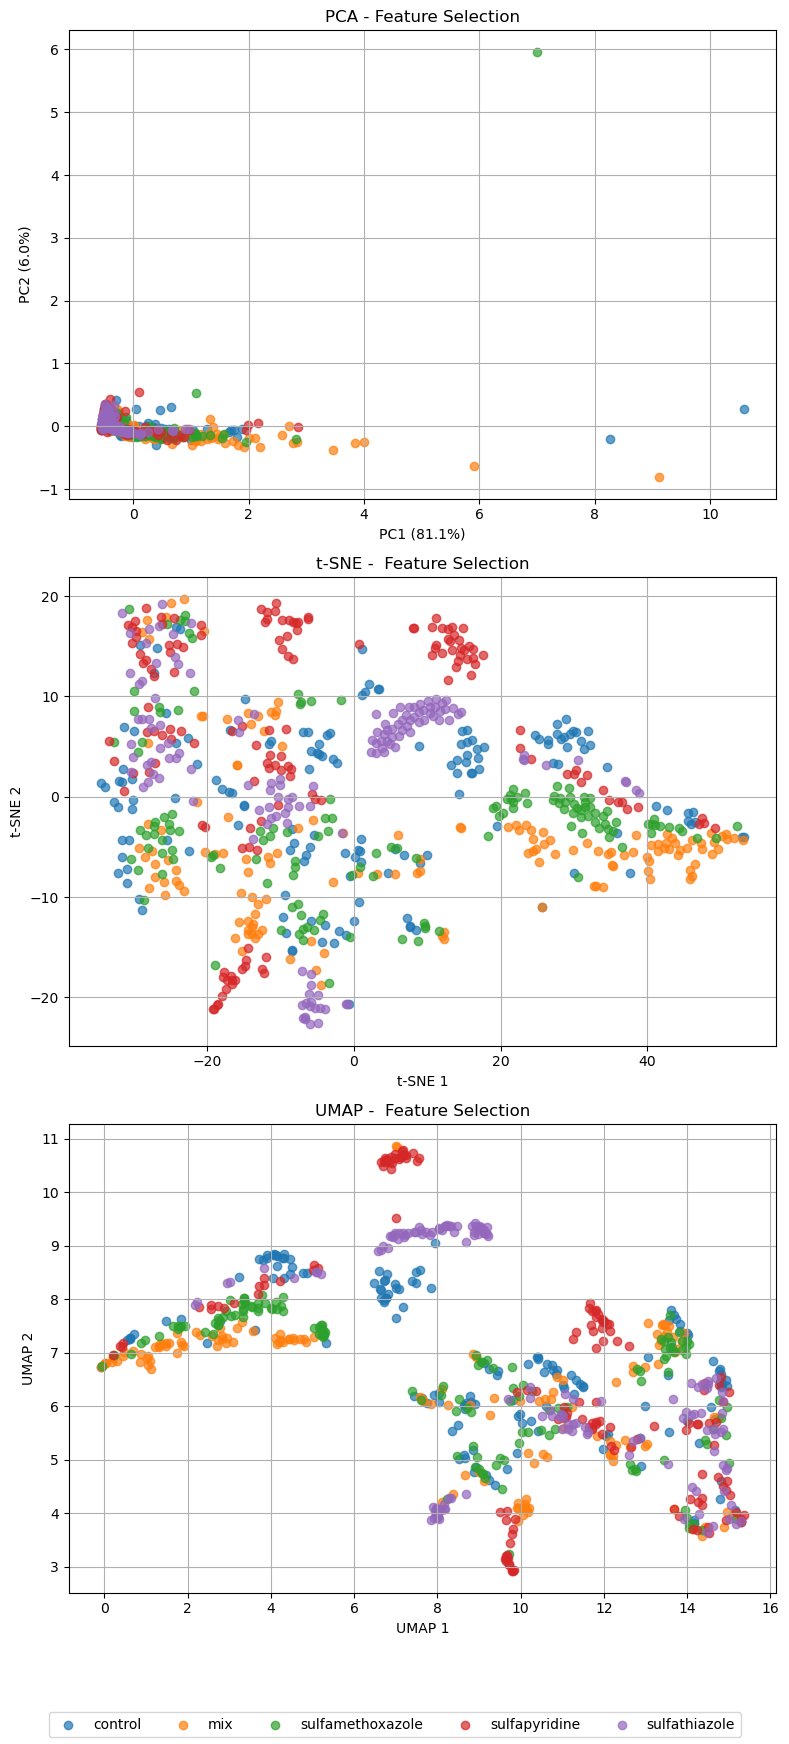

In [ ]:
"""
.py for the application of unsupervised analysis methods on the 

data of the raman spectra after it as been --preprocessed--

"""

#imports for the preprocessing pipeline
import copy
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from pybaselines.whittaker import drpls
import ramanspy as rp
import matplotlib.pyplot as plt

#imports for the unsupervised methods
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

"""
Handeling of the dataset

"""

# Load Excel file, no header row, commas as decimal points
file_path = "C:\\Users\\UTILIZADOR\\Desktop\\Projeto\\Envi\\raw_feat.xlsx"
df = pd.read_excel(file_path, header=None, decimal=',')

# Step 1: Extract wavenumbers from first row, skip column A, exclude last 3 metadata columns
wavenumbers = df.iloc[0, 1:-3].astype(float).values

# Step 2: Extract intensity data (all rows except first, skip column A, exclude metadata)
intensity_data = df.iloc[1:, 1:-3].astype(float).values

# Step 3: Extract metadata (from last 3 columns)
labels = df.iloc[1:, -3].values
concentrations = df.iloc[1:, -2].values
names = df.iloc[1:, -1].values

# Step 4: Build list of spectra
raman_spectra = []
metadata = []

for i in range(intensity_data.shape[0]):
    y_array = intensity_data[i, :]
    spectrum = [wavenumbers, y_array]
    raman_spectra.append(spectrum)
    metadata.append({
        'label': labels[i],
        'concentration': concentrations[i],
        'name': names[i]
    })


"""
Pre-processing of the raman spectra

"""

def cropper(raman_spectrum, *intervals):
    x = np.array(raman_spectrum[0])
    y = np.array(raman_spectrum[1])

    for interval in intervals:
        min_value, max_value = interval
        indices_to_keep = np.where((x >= min_value) & (x <= max_value))
        x = x[indices_to_keep]
        y = y[indices_to_keep]

    return [x, y]


def whitaker_hayes(raman_spectrum, threshold=6):  #threshold=8
        y_array = raman_spectrum[1]
        median_y = np.median(y_array)
        std_y = np.std(y_array)
        cosmic_rays = np.abs(y_array - median_y) > threshold * std_y
        x_array = raman_spectrum[0]
        x_cosmic = x_array[cosmic_rays]
        f_interp = interp1d(x_array[~cosmic_rays], y_array[~cosmic_rays], kind='quadratic', fill_value='extrapolate') # kind='quadratic'
        y_array[cosmic_rays] = f_interp(x_cosmic)
        return np.array([x_array, y_array])


def denoise_spectrum(raman_spectrum, window_size=15, poly_order=2):# window_size=15, poly_order=2 
        x_array = raman_spectrum[0]
        y_array = raman_spectrum[1]
        window_size = window_size + 1 if window_size % 2 == 0 else window_size
        denoised_y = savgol_filter(y_array, window_size, poly_order)
        return np.array([x_array, denoised_y])


def DRPLS(raman_spectrum, smoothing):
        x_array, y_array = raman_spectrum
        baseline_tuple = drpls(y_array, lam=smoothing, diff_order=2, max_iter=500, tol=0.001, weights=None, x_data=x_array, eta=1.00) #diff_order=2 eta=1.0
        baseline_subtracted_y = y_array - baseline_tuple[0]
        return np.array([x_array, baseline_tuple[0]]), np.array([x_array, baseline_subtracted_y])


def cof_normalize(raman_spectrum): # 1405, 1735
        max_y = None
        for x, y in zip(raman_spectrum[0], raman_spectrum[1]):
            if 1590 <= x <= 1610:
                if max_y is None or y > max_y:
                    max_y = y
        raman_data = raman_spectrum[1] / max_y
        return np.array([raman_spectrum[0], raman_data])



"""
Application of the prepro pipeline

"""

processed_spectra = []

# Process all spectra in a loop
for spectrum in raman_spectra:
    lis_spectrum = tuple(arr.tolist() for arr in spectrum)
    original_spectrum = copy.deepcopy(lis_spectrum)

    # Step 1: Crop
    data_crop = cropper(copy.deepcopy(original_spectrum), (300, 2000))

    # Step 2: Cosmic Ray Removal
    data_hay = whitaker_hayes(copy.deepcopy(data_crop))

    # Step 3: Smoothing
    data_den = denoise_spectrum(copy.deepcopy(data_hay))

    # Step 4: Baseline Correction
    _, data_DRP = DRPLS(copy.deepcopy(data_den), 10000)

    # Step 5: Normalization
    data_norm = cof_normalize(copy.deepcopy(data_DRP))

    # Step 6: Final Crop and Sort
    data_crop_f = cropper(copy.deepcopy(data_norm), (400, 2000))
   

    processed_spectra.append(copy.deepcopy(data_crop_f))

#The processed spectra needs to be adjusted for the unsupervised methods 

PCA_ready_processed_spectra = np.array([spectrum[1] for spectrum in processed_spectra])


"""
PCA:

Principal Component Analysis - dimensionality reduction technique 
that allows linear projection of a reduced representation of
the data capturing key spectral variations with pricipal components.

"""


# 1. Create and adjust PCA model
n_components = 2  
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(PCA_ready_processed_spectra)

# 2.  vizualize explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by {n_components} components:", explained_variance)


# 3. 2D vizualization of the PC´s
plt.figure(figsize=(8,6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
plt.title("PCA - Preprocessed")
plt.legend()
plt.grid(True)
plt.show()


"""
T-SNE

t-Distributed Stochastic Neighbour Embedding - dimensionality reduction technique 
which effectively preserves relationships in high-dimensional data but 
requires further parameter tuning

n_components=2: Reduces the data to 2 dimensions.

perplexity=30: A common value (adjustable based on the number of samples, ideally between 5 and 50).

init='pca': Initializes with PCA (helps with stability).

learning_rate='auto': Recommended starting from scikit-learn version 1.2.
"""


# 1. Create and adjust T-SNE model

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(PCA_ready_processed_spectra)


# 2. Results vizualization
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Preprocessed")
plt.legend()
plt.grid(True)
plt.show()


"""
UMAP

Uniform Manifold Approximation and Projection - dimensionality reduction technique 
that maintains local and global data structure 
while being computationally efficient.

n_components=2: Number of output dimensions (2D, 3D...).

n_neighbors=15: Controls the balance between local and global structure.

min_dist=0.1: Controls how close points can get in the reduced space.

metric='euclidean': Distance metric (can be 'cosine', 'manhattan', etc.).
"""

#Create and adjust UMAP model 

umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = umap.fit_transform(PCA_ready_processed_spectra)

#Vizualize results 
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP - Preprocessed")
plt.legend()
plt.grid(True)
plt.show()


"""
Plot all preprocessed plots
"""

# Create vertical stack of subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 18))  # Width x Height

# PCA plot
for label in np.unique(labels):
    idx = labels == label
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
axes[0].set_title("PCA - Preprocessed")
axes[0].set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
axes[0].grid(True)

# t-SNE plot
for label in np.unique(labels):
    idx = labels == label
    axes[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.7)
axes[1].set_title("t-SNE - Preprocessed")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True)

# UMAP plot
for label in np.unique(labels):
    idx = labels == label
    axes[2].scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.7)
axes[2].set_title("UMAP - Preprocessed")
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].grid(True)

# Unified legend (once, at the bottom)
handles, labels_unique = axes[2].get_legend_handles_labels()
fig.legend(handles, labels_unique, loc='lower center', ncol=len(np.unique(labels)))

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # reserve space for legend & title
plt.show()



"""
Pearson corelation matrix

"""

df_intensity = pd.DataFrame(PCA_ready_processed_spectra)

correlation_matrix = df_intensity.corr(method='pearson')

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, xticklabels=False, yticklabels=False)
plt.title("Pearson Correlation Matrix (Wavenumbers)")
plt.show()



"""
Feature Selection

Highly correlated wavenumbers are removed to reduce dimensionality 

"""

# Correlation matrix and upper triangle
corr_matrix = df_intensity.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df_reduced = df_intensity.drop(columns=to_drop)



"""
PCA - after feature selection

"""
# intensity_data já contém os espectros (amostras x variáveis = linhas x wavenumbers)

# 1. Create and adjust PCA model
n_components = 2  
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(df_reduced)

# 2.  vizualize explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by {n_components} components:", explained_variance)


# 3. 2D vizualization of the PC´s
plt.figure(figsize=(8,6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
plt.title("PCA - Feature Selection")
plt.legend()
plt.grid(True)
plt.show()



"""
T-SNE

t-Distributed Stochastic Neighbour Embedding - dimensionality reduction technique 
which effectively preserves relationships in high-dimensional data but 
requires further parameter tuning

n_components=2: Reduces the data to 2 dimensions.

perplexity=30: A common value (adjustable based on the number of samples, ideally between 5 and 50).

init='pca': Initializes with PCA (helps with stability).

learning_rate='auto': Recommended starting from scikit-learn version 1.2.
"""


# 1. Create and adjust T-SNE model

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(df_reduced)


# 2. Results vizualization
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Feature Selection")
plt.legend()
plt.grid(True)
plt.show()


"""
UMAP

Uniform Manifold Approximation and Projection - dimensionality reduction technique 
that maintains local and global data structure 
while being computationally efficient.

n_components=2: Number of output dimensions (2D, 3D...).
df_reduced
n_neighbors=15: Controls the balance between local and global structure.

min_dist=0.1: Controls how close points can get in the reduced space.

metric='euclidean': Distance metric (can be 'cosine', 'manhattan', etc.).
"""

#Create and adjust UMAP model 

umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = umap.fit_transform(df_reduced)

#Vizualize results 
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP - Feature Selection")
plt.legend()
plt.grid(True)
plt.show()



"""
Plot all Feature Selection Plots
"""

# Create vertical stack of subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 18))  # Width x Height

# PCA plot
for label in np.unique(labels):
    idx = labels == label
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
axes[0].set_title("PCA - Feature Selection")
axes[0].set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
axes[0].grid(True)

# t-SNE plot
for label in np.unique(labels):
    idx = labels == label
    axes[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.7)
axes[1].set_title("t-SNE -  Feature Selection")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True)

# UMAP plot
for label in np.unique(labels):
    idx = labels == label
    axes[2].scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.7)
axes[2].set_title("UMAP -  Feature Selection")


axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].grid(True)

# Unified legend (once, at the bottom)
handles, labels_unique = axes[2].get_legend_handles_labels()
fig.legend(handles, labels_unique, loc='lower center', ncol=len(np.unique(labels)))

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # reserve space for legend & title

No kernel connected

No kernel connected

No kernel connected